In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import rcParams

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

chamber_list = [7, 6, 19, 20, 11, 13, 4, 8, 16, 17, 10]
chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}
xticklabels = ['TAMB', 'T0.00', 'T2.25', 'T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

In [2]:
"""
Annual maximum LAI observation unit conversion notes: 

The PFT-level model output should be multiplied by the PFT fraction (0.36 = pima, 0.14 = lala, 0.25 = shrub) to get the plot average number. 

Also, Paul's number here is for the entire enclosure (114.8 m2), while these model results were just simulating the area within the boardwalks (66.4 m2)

So for the best comparison against model LAI, Paul's number here is multiplied by 114.8/66.4/(frac_PFT) = 4.8 for pima, 12.3 for lala, 6.9 for shrub.

When we next optimize the model, we'll use these numbers from Paul and set up the simulation to represent the whole enclosure to better match his numbers.
"""
year_list    = range(2015, 2022)
pft_list     = ['2', '3', '11']

data = pd.read_excel(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                                  'LAI Record_30Jun2021.xlsx'),
                     sheet_name = 'Pivot By Veg Type and Plot Copy', usecols = 'A:D')
data['Year'] = data['Year'].astype(int)
data['Plot'] = data['Plot'].astype(int)
data = data.set_index(['Year', 'Plot', 'Vegetation type'])

annual_lai = pd.DataFrame(np.nan, 
                          columns = pd.MultiIndex.from_product([pft_list, 
                                                                chambers_ordered['amb'] + \
                                                                chambers_ordered['elev']]), 
                          index = year_list)

for i in range(len(chamber_list)):
    for j, (pft, name) in enumerate(zip(['2','3','11'], 
                                        ['Evergreen Tree', 'Deciduous Tree', 'Shrub'])):
        for k in year_list:
            if k == 2021:
                continue
            if (k == 2020) & (pft == '11'):
                continue
            temp = float(data.loc[(k, chamber_list[i], name), 'Sum of LAI'])
            # adjust the area of the LAI to the area of the chamber
            annual_lai.loc[k, (pft, str(chamber_list[i]))] = temp * 114.8 / 66.4

In [3]:
# Read the modeled annual maximum TLAI
prefix_list = ['20231116', 'UQ_20231116', 'UQ_20240101', 'UQ_20240102']
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
pft_names = ['Spruce', 'Tamarack', 'Shrub']
frac_list = [0.36, 0.14, 0.25]
collection_gs = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                         'extract', prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    temp_data = temp_data.loc[:, (slice(None), 'TLAI')]
    temp_data.columns = temp_data.columns.droplevel(1)

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)
    for p, pft in enumerate([2, 3, 11]):
        temp_data.loc[:, str(pft)] = temp_data.loc[:, str(pft)].values * frac_list[p]
    temp_data = temp_data.loc[:, ['2','3','11']]

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    temp_annual = temp_data.loc[filt, :].resample('1Y').max()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['pft', 'plot'])    
    collection_gs[prefix] = temp_annual.sort_index(axis = 1)

/tmp/ipykernel_3348205/1428650215.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_3348205/1428650215.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_3348205/1428650215.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_3348205/1428650215.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1


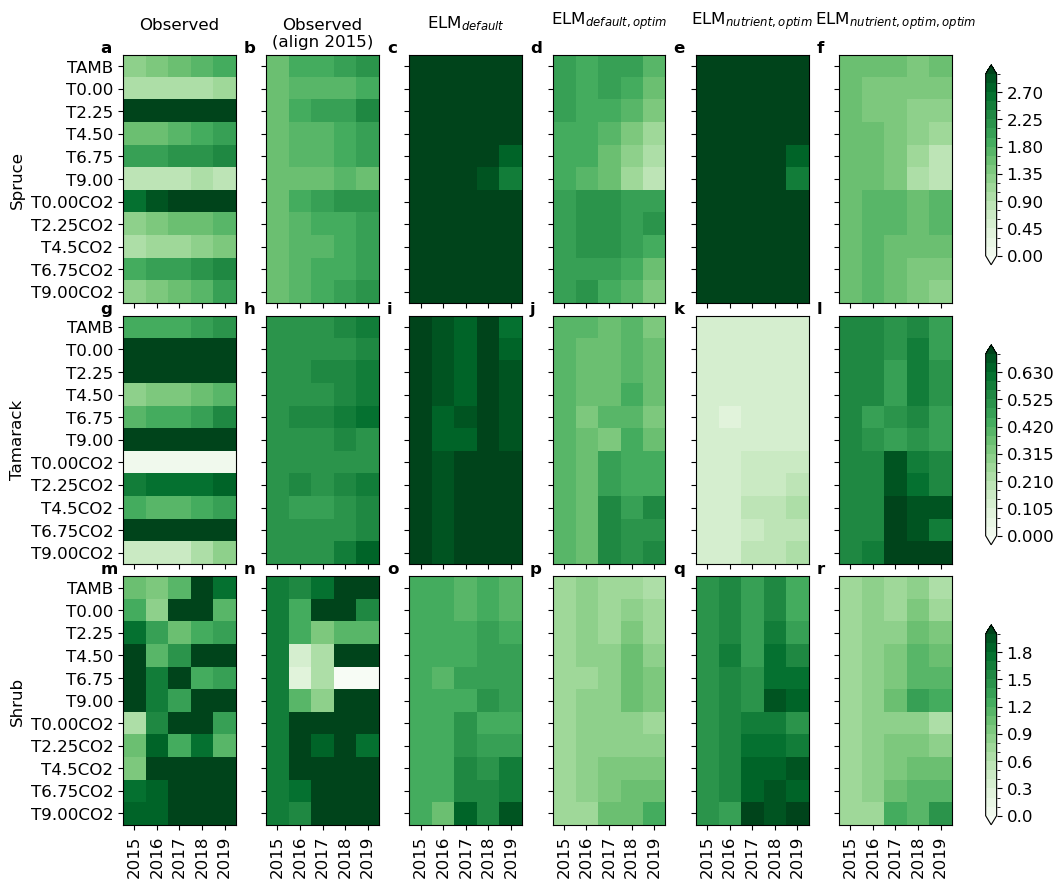

In [4]:
fig, axes = plt.subplots(3, 2 + len(prefix_list), figsize = (11, 10), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.05, wspace = 0.05)
labs = 'abcdefghijklmnopqrstuvwxyz'
count = 0
for i, (pft,name) in enumerate(zip(['2','3','11'], ['Spruce','Tamarack','Shrub'])):
    ##if 'UQ' in prefix_default:
    if i == 0:
        norm = BoundaryNorm(boundaries=np.linspace(0, 3, 21), ncolors=256, extend = 'both')
    elif i == 1:
        norm = BoundaryNorm(boundaries=np.linspace(0, 0.7, 21), ncolors=256, extend = 'both')
    else:        
        norm = BoundaryNorm(boundaries=np.linspace(0, 2, 21), ncolors=256, extend = 'both')
    ##else:
    ##    if i == 0:
    ##        norm = BoundaryNorm(boundaries=np.linspace(0, 6, 21), ncolors=256, extend = 'both')
    ##    elif i == 1:
    ##        norm = BoundaryNorm(boundaries=np.linspace(0, 1.5, 21), ncolors=256, extend = 'both')
    ##    else:        
    ##        norm = BoundaryNorm(boundaries=np.linspace(0, 5, 21), ncolors=256, extend = 'both')

    ax = axes[i, 0]
    temp = annual_lai.loc[:2019, pft]
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T
    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[:-2], rotation = 90)
    ax.set_yticks(range(len(xticklabels)))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed\n ')
    ax.set_ylabel(name)
    ax.text(-0.2, 1.01, labs[count], transform = ax.transAxes, fontdict={'weight': 'bold'})
    count += 1

    ax = axes[i, 1]
    temp = annual_lai.loc[:2019, pft] - annual_lai.loc[2015, pft] + \
           annual_lai.loc[2015, pft].mean()
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T
    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[:-2], rotation = 90)
    ax.set_yticks(range(len(xticklabels)))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed\n(align 2015)')
    ax.text(-0.2, 1.01, labs[count], transform = ax.transAxes, fontdict={'weight': 'bold'})
    count += 1

    for j, (prefix,case) in enumerate(zip(prefix_list, name_list)):
        ax = axes[i,j+2]
        temp = collection_gs[prefix].loc[:2019, pft]
        temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp = temp.T
        cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
        ax.set_xticks(range(len(year_list[:-2])))
        ax.set_xticklabels(year_list[:-2], rotation = 90)
        ax.set_yticks(range(len(xticklabels)))
        ax.set_yticklabels(xticklabels)
        if i == 0:
            ax.set_title(case+'\n ')
        ax.text(-0.2, 1.01, labs[count], transform = ax.transAxes, fontdict={'weight': 'bold'})
        count += 1

    cax = fig.add_axes([0.92, 0.67 - 0.28 * i, 0.01, 0.2])
    plt.colorbar(cf, cax = cax, orientation = 'vertical')

In [5]:
""" Observed annual aboveground biomass from Verity's data 
Skip because this is controlled too much by r_mort
"""
obs_data = pd.read_csv(os.path.join(os.environ['HOME'],
    'Git', 'phenology_elm', 'SalmonSPRUCE_2016to2021_AbovegroundPFT_CNPbudget_20240208.csv'))
# match by plot and year to temperature
obs_data['Plot'] = [f'P{p:02d}' for p in obs_data['Plot']]
obs_data = obs_data.set_index(['Plot', 'Year', 'PFT']).unstack()
obs_data = obs_data.loc[:, (slice(None), 
                            ['Sphagnum', 'evergreen conifer', 'deciduous conifer',  
                             'shrub'])]
obs_data = obs_data.loc[:, ['ABGbiomass_gCperm2', 'Pretrt_ABGbiomass_gCperm2']]


annual_biomass = pd.DataFrame(np.nan, 
                              columns = pd.MultiIndex.from_product([pft_list, 
                                                                    chambers_ordered['amb'] + \
                                                                    chambers_ordered['elev']]), 
                              index = year_list)
for pft, name in zip(['2','3','11','12'], 
                     ['evergreen conifer', 'deciduous conifer', 'shrub', 'Sphagnum']):
    # biomass observations do not have TAMB (plot 07)
    for chamber in chamber_list[1:]:
        annual_biomass.loc[2015, (str(pft), str(chamber))] = \
            obs_data.loc[(f'P{chamber:02d}',2016), ('Pretrt_ABGbiomass_gCperm2', name)]
        annual_biomass.loc[2016:2021, (str(pft), str(chamber))] = \
            obs_data.loc[f'P{chamber:02d}', ('ABGbiomass_gCperm2', name)].values

In [6]:
# Read the modeled annual mean biomass
prefix_list = ['20231116', 'UQ_20231116', 'UQ_20240101', 'UQ_20240102']
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
pft_names = ['Spruce', 'Tamarack', 'Shrub']
pft_frac = [0.36, 0.14, 0.25]
collection_gs = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                         'extract', prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    temp_data = temp_data.loc[:, (slice(None), 'TOTVEGC_ABG')]
    temp_data.columns = temp_data.columns.droplevel(1)
    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['pft','plot'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    for p, pft in enumerate([2, 3, 11]):
        temp_data.loc[:, str(pft)] = temp_data.loc[:, str(pft)].values * frac_list[p]
    temp_data = temp_data.loc[:, ['2','3','11']]

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    temp_annual = temp_data.loc[filt, :].resample('1Y').max()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['pft', 'plot'])    
    collection_gs[prefix] = temp_annual.sort_index(axis = 1)

/tmp/ipykernel_3348205/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_3348205/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_3348205/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_3348205/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1


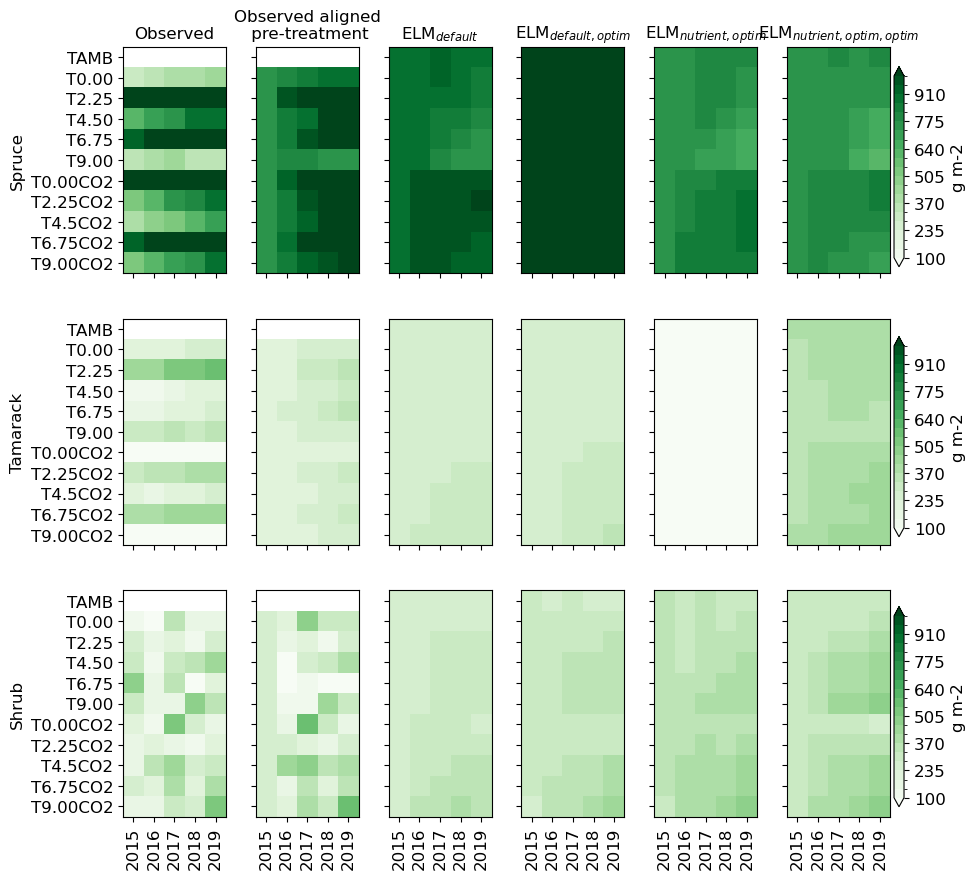

In [7]:
norm = BoundaryNorm(boundaries=np.linspace(100, 1000, 21), 
                    ncolors=256, extend = 'both')

fig, axes = plt.subplots(3, 2+len(prefix_list), figsize = (10, 10), sharex = True, sharey = True)
for i, (pft,name) in enumerate(zip(['2','3','11'], ['Spruce','Tamarack','Shrub'])):
    ax = axes[i, 0]
    temp = annual_biomass.loc[:2019, pft]
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T
    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[:-2], rotation = 90)
    ax.set_yticks(range(11))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed')
    ax.set_ylabel(name)

    ax = axes[i, 1]
    temp = annual_biomass.loc[:2019, pft] - annual_biomass.loc[2015, pft] + \
           annual_biomass.loc[2015, pft].mean()
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T
    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[:-2], rotation = 90)
    ax.set_yticks(range(11))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed aligned\n pre-treatment')

    for j, (prefix,case) in enumerate(zip(prefix_list, name_list)):
        ax = axes[i,j+2]
        temp = collection_gs[prefix].loc[:2019, pft]
        temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp = temp.T
        cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
        ax.set_xticks(range(len(year_list[:-2])))
        ax.set_xticklabels(year_list[:-2], rotation = 90)
        ax.set_yticks(range(11))
        ax.set_yticklabels(xticklabels)
        if i == 0:
            ax.set_title(case)

    cax = fig.add_axes([0.9, 0.12 + 0.27 * i, 0.01, 0.2])
    plt.colorbar(cf, cax = cax, orientation = 'vertical', label = 'g m-2')